In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [38]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               143 non-null    object 
 1   Step                    143 non-null    object 
 2   Input Tokens (Prompt)   143 non-null    int64  
 3   Output Tokens (Answer)  143 non-null    int64  
 4   Total Tokens            143 non-null    int64  
 5   Latency (s)             143 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.8+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,143.000000,143.000000,143.000000,143.000000
mean,7871.307692,197.601399,8760.797203,3.103427
std,10580.341449,262.665592,11708.411920,2.990377
min,474.000000,3.000000,736.000000,0.590000
25%,755.500000,15.000000,1136.000000,0.925000
50%,1215.000000,73.000000,1885.000000,1.330000
75%,9425.000000,308.000000,9434.000000,5.115000
max,27883.000000,1164.000000,54691.000000,10.590000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79


In [39]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if '_Naive' in x else 'FRB' if '_FRB' in x else 'HRB')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-06-06 13:37:41,Router_HRB,9428,18,9446,1.28,0,HRB
1,2026-06-06 13:37:56,Generator_HRB,810,873,2458,9.67,775,HRB
2,2026-06-06 13:38:01,Evaluator_HRB,1663,60,1723,0.82,0,HRB
3,2026-06-06 13:39:13,Generator_FRB,487,804,1483,6.33,192,FRB
4,2026-06-06 13:39:19,Evaluator_FRB,1272,55,1327,0.79,0,FRB


In [40]:
step_token_usage_df = df.groupby(['Step', 'Model'])[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].mean().reset_index() 
display(step_token_usage_df)
step_time_usage_df = df.groupby(['Step', 'Model'])['Latency'].mean().reset_index()
display(step_time_usage_df)

model_token_usage_df = step_token_usage_df.groupby('Model')[['Input Tokens', 'Output Tokens', 'Extra Tokens', 'Total Tokens']].sum().reset_index()
display(model_token_usage_df)
model_time_usage_df = step_time_usage_df.groupby('Model')['Latency'].sum().reset_index()
display(model_time_usage_df)

,Step,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,Evaluator_FRB,FRB,1439.666667,61.111111,0.000000,1500.777778
1,Evaluator_HRB,HRB,1208.277778,52.888889,0.000000,1261.166667
2,Evaluator_Naive,Naive,27022.562500,48.062500,0.125000,27070.750000
3,Generator_FRB,FRB,1010.157895,547.789474,857.631579,2415.578947
4,Generator_HRB,HRB,880.736842,454.578947,620.947368,1956.263158
5,Generator_Naive,Naive,26626.125000,374.687500,4424.687500,31425.500000
6,Router_FRB,FRB,747.210526,13.578947,1.578947,762.368421
7,Router_HRB,HRB,9412.833333,7.666667,1.111111,9421.611111


,Step,Model,Latency
0,Evaluator_FRB,FRB,0.982778
1,Evaluator_HRB,HRB,1.005556
2,Evaluator_Naive,Naive,1.501250
3,Generator_FRB,FRB,6.711053
4,Generator_HRB,HRB,6.389474
5,Generator_Naive,Naive,6.266250
6,Router_FRB,FRB,0.825789
7,Router_HRB,HRB,1.062222


,Model,Input Tokens,Output Tokens,Extra Tokens,Total Tokens
0,FRB,3197.035088,622.479532,859.210526,4678.725146
1,HRB,11501.847953,515.134503,622.058480,12639.040936
2,Naive,53648.687500,422.750000,4424.812500,58496.250000


,Model,Latency
0,FRB,8.519620
1,HRB,8.457251
2,Naive,7.767500


## Plots

### Cmap

In [41]:
# Colormap for each Step category

FRB = "#1F77B4"
HRB = "#328F3A"
full_db = "#f93e3e"

step_cmap = {
    'Router_FRB': FRB,
    'Generator_FRB': FRB,
    'Evaluator_FRB': FRB,

    'Router_HRB': HRB,
    'Generator_HRB': HRB,
    'Evaluator_HRB': HRB,

    'Generator_Naive': full_db,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'FRB': FRB,
    'HRB': HRB,
    'Naive': full_db
}

### Comparison

#### Average token per model

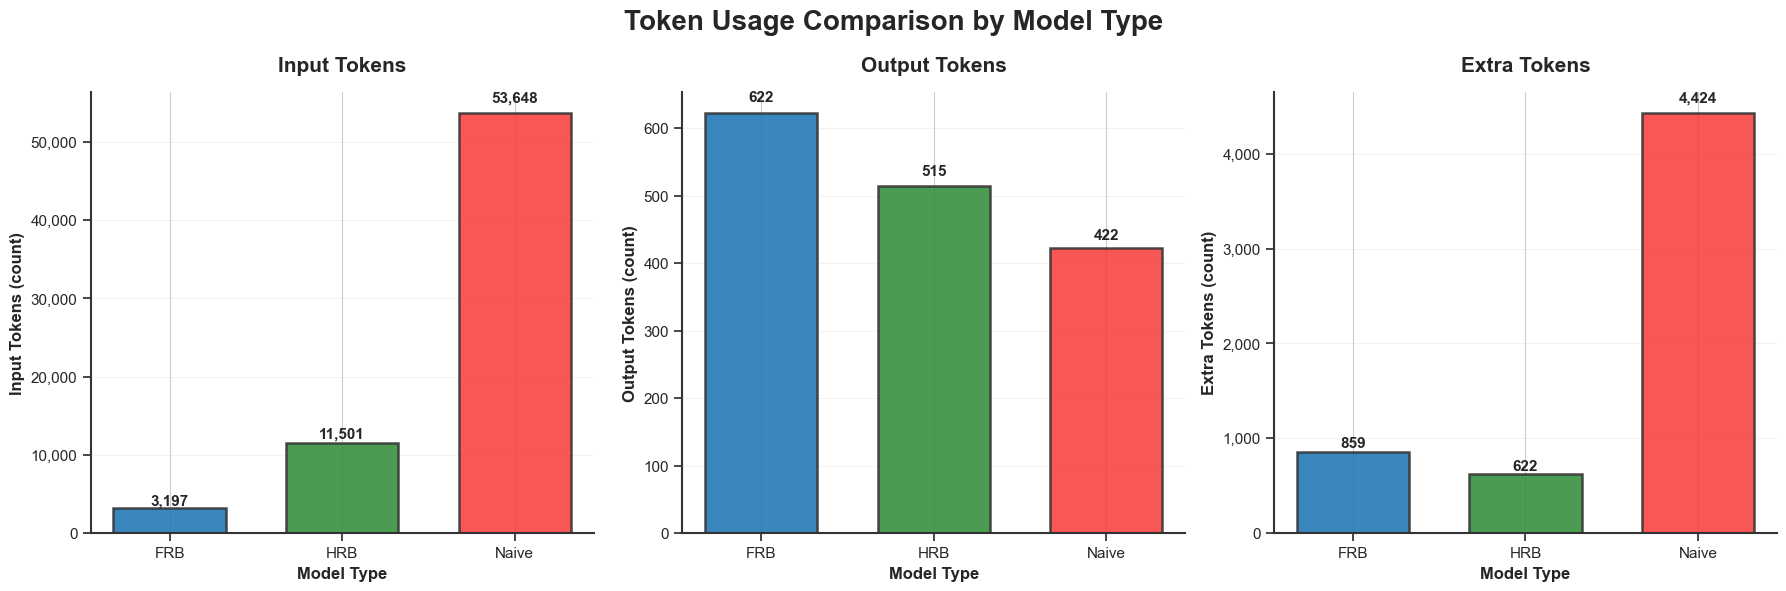

In [42]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes_flat[idx]
    
    bars = ax.bar(model_token_usage_df['Model'], model_token_usage_df[metric], 
                   color=[model_cmap[model] for model in model_token_usage_df['Model']],
                   edgecolor='#333333', linewidth=1.8, alpha=0.88, width=0.65)
    
    ax.set_title(f'{metric}', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(f'{metric} (count)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model Type', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
    ax.tick_params(axis='y', which='minor', labelsize=10)
    
    # Format y-axis with thousand separators
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Add value labels on bars with better formatting
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.02,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

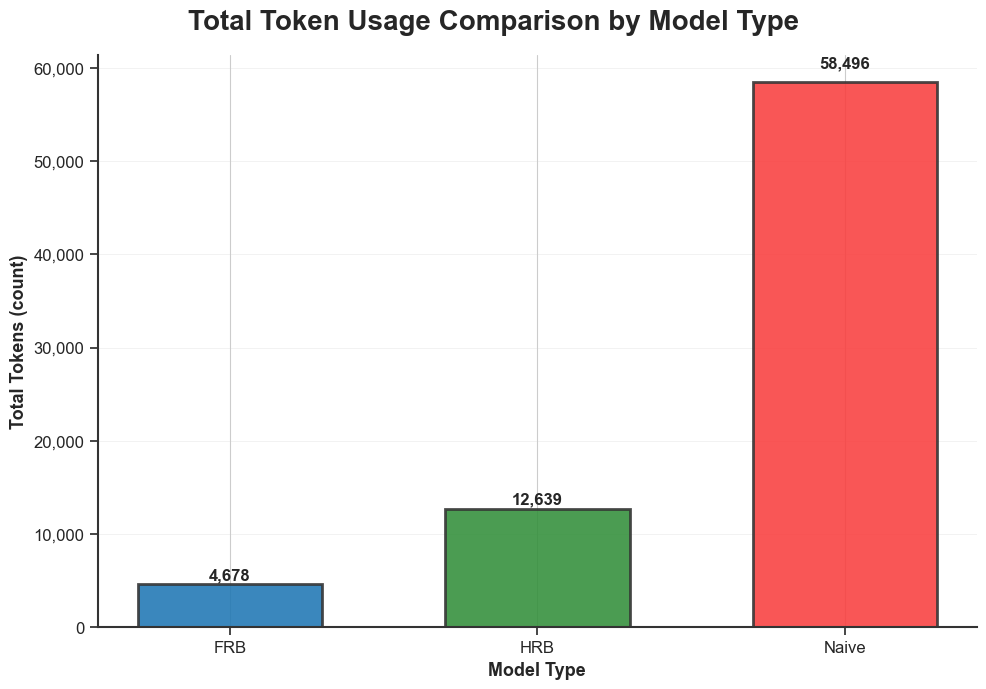

In [43]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Token Usage Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_token_usage_df['Model'],
    model_token_usage_df['Total Tokens'],
    color=[model_cmap[model] for model in model_token_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Tokens (count)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

# Format y-axis with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        #family='serif'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

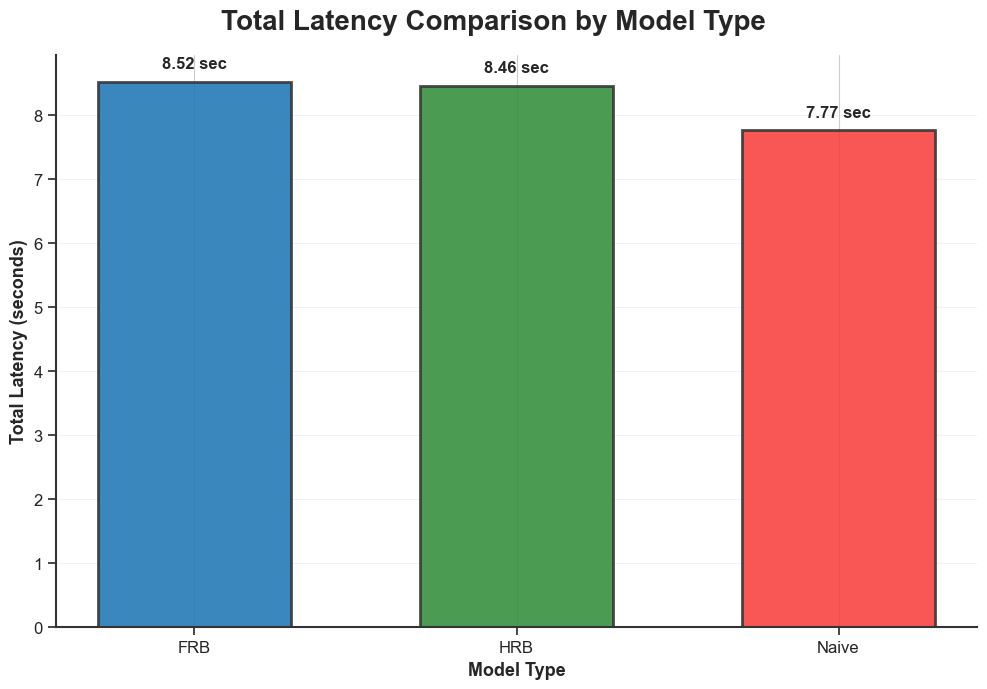

In [44]:
# Set academic style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['grid.linewidth'] = 0.8
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Total Latency Comparison by Model Type', fontsize=20, fontweight='bold', y=0.98)

bars = ax.bar(
    model_time_usage_df['Model'],
    model_time_usage_df['Latency'],
    color=[model_cmap[model] for model in model_time_usage_df['Model']],
    edgecolor='#333333',
    linewidth=2,
    alpha=0.88,
    width=0.6
)

ax.set_ylabel('Total Latency (seconds)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model Type', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='-', linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='both', which='major', labelsize=12, length=6, width=1.2)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height * 1.02,
        f'{height:.2f} sec',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
plt.show()

In [45]:
print(df['Step'].value_counts())
print('\n')
print(df['Model'].value_counts())

Step
Generator_HRB      19
Generator_FRB      19
Router_FRB         19
Router_HRB         18
Evaluator_HRB      18
Evaluator_FRB      18
Generator_Naive    16
Evaluator_Naive    16
Name: count, dtype: int64


Model
FRB      56
HRB      55
Naive    32
Name: count, dtype: int64
